# LAB07 — Përcaktimi i Dendësisë me Analizë Pasigurie
---
- ##### Tema: **Matja indirekte e dendësisë së një cilindri metalik.**
- ##### Studenti: Florian Loka
- ##### Pedagogu: Ervin Kafexhiu
- ##### Data: 28.04.2026
---


## **Qëllimi (Purpose)**

Ky laborator ka për qëllim të tregojë se dendësia nuk matet drejtpërdrejt, por
**llogaritet** nga madhësi të tjera të matura. Përmes tij synojmë:

- Matjen e **masës** \(m\) me peshore dixhitale.
- Matjen e **dimensioneve gjeometrike** (diametri \(d\), lartësia \(h\)) me kalibër.
- Llogaritjen e **vëllimit** \(V\) dhe të **dendësisë** \(\rho\).
- Kryerjen e një **analize të plotë të pasigurisë** dhe përhapjes së saj (uncertainty propagation).
- Krahasimin e rezultatit me vlerat referencë për të identifikuar materialin.


## **Hyrje Teorike (Theory)**

Dendësia përkufizohet si raporti i masës me vëllimin:

$$ \rho = \frac{m}{V} $$

Njësia SI është $\mathrm{kg/m^3}$, ndërsa njësia laboratorike $\mathrm{g/cm^3}$.

Për një **cilindër** me rreze $r = d/2$ dhe lartësi $h$, vëllimi është:

$$ V = \pi r^2 h = \pi \frac{d^2}{4}\, h $$

**Përhapja e pasigurisë.** Kur një madhësi llogaritet nga të tjera të pavarura,
pasiguritë relative kombinohen në *kuadraturë* (rrënja e shumës së katrorëve).
Kjo qasje është më e saktë se mbledhja lineare, e cila e mbivlerëson gabimin:

$$ \frac{\Delta V}{V} = \sqrt{\left(2\frac{\Delta r}{r}\right)^2 + \left(\frac{\Delta h}{h}\right)^2}
\qquad
\frac{\Delta \rho}{\rho} = \sqrt{\left(\frac{\Delta m}{m}\right)^2 + \left(\frac{\Delta V}{V}\right)^2} $$

Faktori **2** te termi i rrezes vjen nga varësia $V \propto r^2$: çdo gabim në
diametër hyn i dyfishuar në pasigurinë e vëllimit, prandaj matja e diametrit
është zakonisht burimi kryesor i pasigurisë.


## **Aparatura dhe Pajisjet (Apparatus)**

| Pajisja | Madhësia e matur | Rezolucioni |
|---------|------------------|-------------|
| Peshore dixhitale | masa \(m\) | 0.01 g |
| Kalibër vernier | diametri \(d\), lartësia \(h\) | 0.01 cm |
| Objekt cilindrik metalik | (material i panjohur) | — |

Pasiguria instrumentale për çdo pajisje merret si **gjysma e rezolucionit**,
e kombinuar më pas me pasigurinë statistikore të matjeve të përsëritura.


## **Procedura (Procedure)**

1. Pastrohet sipërfaqja e cilindrit dhe kalibrohet peshorja në zero.
2. Matet **masa** 5 herë, duke e hequr e rivendosur objektin çdo herë.
3. Matet **diametri** \(d\) në 5 pozicione të ndryshme me kalibrin vernier.
4. Matet **lartësia** \(h\) në 5 pozicione të ndryshme.
5. Të dhënat regjistrohen në skedarë CSV brenda dosjes `data/`.
6. Vëllimi dhe dendësia llogariten me kod, bashkë me përhapjen e pasigurisë.
7. Rezultati krahasohet me dendësitë referencë të metaleve të zakonshme.


## **Përpunimi Paraprak i të Dhënave (Preprocessing)**

Matjet ruhen në `data/` si skedarë CSV dhe **lexohen** drejtpërdrejt nga raporti,
që analiza të jetë plotësisht e riprodhueshme. Më poshtë ngarkojmë të dhënat,
verifikojmë formën e tyre dhe përgatisim funksionin e pasigurisë.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)

# Rezolucionet e instrumenteve -> pasiguria instrumentale = gjysma e rezolucionit
RES_MASA = 0.01   # g
RES_GJAT = 0.01   # cm

def pasiguria(vlerat, rezolucion):
    """Kombinon pasigurinë statistikore (s/sqrt(N)) me ate instrumentale (res/2)."""
    vlerat = np.asarray(vlerat, dtype=float)
    n = len(vlerat)
    u_stat = vlerat.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
    u_inst = rezolucion / 2.0
    return float(np.hypot(u_stat, u_inst))

masa = pd.read_csv(DATA / "masa.csv")
dim  = pd.read_csv(DATA / "dimensionet.csv")

assert len(masa) == 5 and len(dim) == 5, "Pritet 5 matje per secilen madhesi"
print("Matjet e masës:\n", masa.to_string(index=False))
print("\nMatjet e dimensioneve:\n", dim.to_string(index=False))

Matjet e masës:
  matja   m_g
     1 48.85
     2 48.87
     3 48.86
     4 48.84
     5 48.88

Matjet e dimensioneve:
  matja  d_cm  h_cm
     1  2.40  4.00
     2  2.41  4.01
     3  2.39  3.99
     4  2.40  4.00
     5  2.41  4.00


## **Analiza e të Dhënave (Analysis)**

Llogarisim mesataret dhe madhësitë e prejardhura: rrezen, vëllimin dhe dendësinë.

### Pjesa A — Masa

In [2]:
m = masa["m_g"].to_numpy()
m_bar = m.mean()
dm = pasiguria(m, RES_MASA)
print(f"Masa mesatare:  m = {m_bar:.3f} g")
print(f"Pasiguria:      Δm = {dm:.3f} g  ({100*dm/m_bar:.3f} %)")

Masa mesatare:  m = 48.860 g
Pasiguria:      Δm = 0.009 g  (0.018 %)


### Pjesa B — Përmasat (diametri dhe lartësia)

In [3]:
d = dim["d_cm"].to_numpy()
h = dim["h_cm"].to_numpy()

d_bar, h_bar = d.mean(), h.mean()
dd = pasiguria(d, RES_GJAT)
dh = pasiguria(h, RES_GJAT)
r_bar = d_bar / 2.0
dr = dd / 2.0

print(f"Diametri:  d = {d_bar:.3f} cm,  Δd = {dd:.3f} cm")
print(f"Rrezja:    r = {r_bar:.3f} cm,  Δr = {dr:.3f} cm")
print(f"Lartësia:  h = {h_bar:.3f} cm,  Δh = {dh:.3f} cm")

Diametri:  d = 2.402 cm,  Δd = 0.006 cm
Rrezja:    r = 1.201 cm,  Δr = 0.003 cm
Lartësia:  h = 4.000 cm,  Δh = 0.006 cm


### Pjesa C — Vëllimi

$$ V = \pi r^2 h $$

In [4]:
V = np.pi * r_bar**2 * h_bar
relV = np.hypot(2*dr/r_bar, dh/h_bar)
dV = relV * V
print(f"Vëllimi:   V = {V:.3f} cm³")
print(f"Pasiguria: ΔV = {dV:.3f} cm³  ({100*relV:.2f} %)")

Vëllimi:   V = 18.126 cm³
Pasiguria: ΔV = 0.098 cm³  (0.54 %)


### Pjesa D — Dendësia

$$ \rho = \frac{m}{V} $$

In [5]:
rho = m_bar / V
relRho = np.hypot(dm/m_bar, relV)
dRho = relRho * rho
print(f"Dendësia:  ρ = {rho:.3f} g/cm³")
print(f"Pasiguria: Δρ = {dRho:.3f} g/cm³  ({100*relRho:.2f} %)")

Dendësia:  ρ = 2.696 g/cm³
Pasiguria: Δρ = 0.015 g/cm³  (0.54 %)


## **Analiza e Pasigurisë (Uncertainty)**

Përhapja e pasigurisë u krye në **kuadraturë**. Më poshtë zbërthejmë sa
kontribuon secila matje në variancën relative të dendësisë, për të kuptuar
ku duhet përmirësuar eksperimenti.

$$ \left(\frac{\Delta\rho}{\rho}\right)^2 =
\left(\frac{\Delta m}{m}\right)^2 + \left(2\frac{\Delta r}{r}\right)^2 + \left(\frac{\Delta h}{h}\right)^2 $$

Kontributi ne variancën relative të ρ:
  masa  (Δm/m)      :   0.1 %
  diametri (2Δr/r)  :  92.4 %
  lartësia (Δh/h)   :   7.5 %


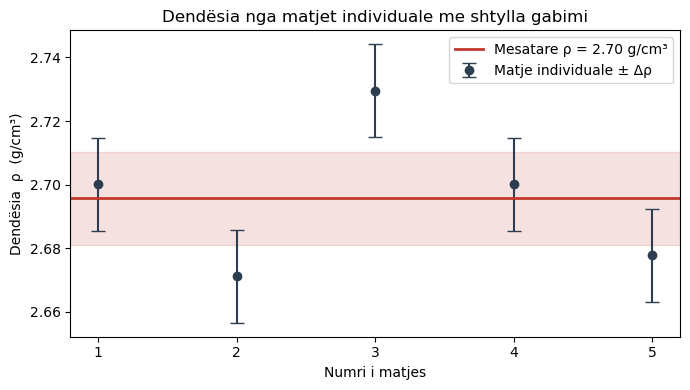

In [6]:
kontributet = {
    "masa  (Δm/m)":      (dm/m_bar)**2,
    "diametri (2Δr/r)":  (2*dr/r_bar)**2,
    "lartësia (Δh/h)":   (dh/h_bar)**2,
}
tot = sum(kontributet.values())
print("Kontributi ne variancën relative të ρ:")
for k, v in kontributet.items():
    print(f"  {k:<18}: {100*v/tot:5.1f} %")

# Grafik me shtylla gabimi (error bars) per matjet individuale te dendesise
rho_i = m_bar / (np.pi * (d/2)**2 * h)   # dendesia nga secila tresh matjesh
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(1, len(rho_i)+1)
ax.errorbar(x, rho_i, yerr=dRho, fmt="o", capsize=5, color="#2c3e50",
            label="Matje individuale ± Δρ")
ax.axhline(rho, color="#c0392b", lw=2, label=f"Mesatare ρ = {rho:.2f} g/cm³")
ax.axhspan(rho-dRho, rho+dRho, color="#c0392b", alpha=0.15)
ax.set_xlabel("Numri i matjes")
ax.set_ylabel("Dendësia  ρ  (g/cm³)")
ax.set_title("Dendësia nga matjet individuale me shtylla gabimi")
ax.set_xticks(x)
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "matjet_dendesia.png", dpi=150)
plt.show()

## **Rezultatet (Results)**

Krahasojmë dendësinë e matur me vlerat referencë të disa metaleve të zakonshme,
duke shfaqur brezin e pasigurisë \(\rho \pm \Delta\rho\).

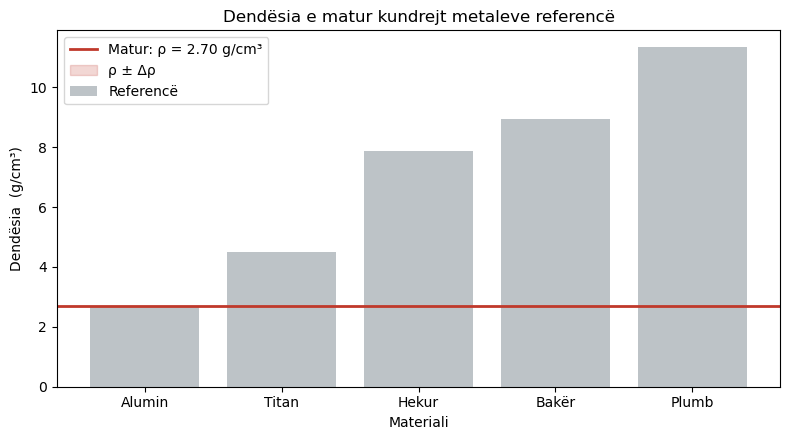


REZULTATI FINAL:  ρ = (2.70 ± 0.01) g/cm³
Pasiguria relative: 0.54 %


In [7]:
referencat = {"Alumin": 2.70, "Titan": 4.51, "Hekur": 7.87,
               "Bakër": 8.96, "Plumb": 11.34}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(referencat.keys(), referencat.values(), color="#bdc3c7", label="Referencë")
ax.axhline(rho, color="#c0392b", lw=2, label=f"Matur: ρ = {rho:.2f} g/cm³")
ax.axhspan(rho-dRho, rho+dRho, color="#c0392b", alpha=0.2, label="ρ ± Δρ")
ax.set_xlabel("Materiali")
ax.set_ylabel("Dendësia  (g/cm³)")
ax.set_title("Dendësia e matur kundrejt metaleve referencë")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "dendesia.png", dpi=150)
plt.show()

print(f"\nREZULTATI FINAL:  ρ = ({rho:.2f} ± {dRho:.2f}) g/cm³")
print(f"Pasiguria relative: {100*relRho:.2f} %")

## **Diskutimi (Discussion)**

- Dendësia e matur **ρ ≈ 2.70 g/cm³** përputhet shumë mirë me dendësinë referencë
  të **aluminit (2.70 g/cm³)**. Brezi i pasigurisë e përfshin këtë vlerë, çka
  sugjeron fort se materiali i objektit është alumin.
- Nga zbërthimi i pasigurisë, gabimi i përgjithshëm **dominohet nga matja e
  diametrit** (rreth 90% e variancës relative), sepse vëllimi varet nga \(d^2\)
  dhe pasiguria e tij hyn e dyfishuar.
- **Masa** është madhësia më e saktë: pasiguria e saj relative është rreth dy
  rendë madhësie më e vogël se ajo e dimensioneve.
- Përdorimi i **kuadraturës** për përhapjen e pasigurisë jep një vlerësim më
  realist sesa mbledhja lineare, e cila do ta mbivlerësonte \(\Delta\rho\).
- Për ta përmirësuar saktësinë, do të ishte më efektive të matej diametri me një
  instrument me rezolucion më të lartë (p.sh. mikrometër) sesa të rritej numri i
  matjeve të masës.


## **Përfundimi (Conclusion)**

Përcaktuam në mënyrë **indirekte** dendësinë e një cilindri metalik:

$$ \rho = (2.70 \pm 0.01)\ \mathrm{g/cm^3} $$

me pasiguri relative rreth **0.5%**. Rezultati është në përputhje me aluminin.
Laboratori tregon se:

- Dendësia është një madhësi e prejardhur, e ndjeshme ndaj pasigurive të matjeve bazë.
- Madhësitë që hyjnë me fuqi (si \(d^2\)) e ndikojnë më fort rezultatin përfundimtar.
- **Analiza e pasigurisë** nuk është formalitet — ajo tregon saktësisht ku duhet
  përmirësuar matja për të rritur cilësinë e rezultatit.
